## Basic

1. Define the State — the typed object that every node reads and writes:

In [1]:
from langgraph.graph import StateGraph, MessagesState

# MessagesState is a built-in: just a list of messages + add_messages reducer
graph = StateGraph(MessagesState)

In [2]:
print(graph)

In [33]:
from typing import Annotated, List, TypedDict
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages
from typing import TypedDict

class State(TypedDict):
    graph_state: str
class MessageState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

In [34]:
def node_1(state: State):
    print('----node1----')
    return {'graph_state' : state['graph_state'] + 'I am'}

def node_2(state: State):
    print('----node2----')
    return {'graph_state' : state['graph_state'] + ' Happy'}

def node_3(state: State):
    print('----node3----')
    return {'graph_state' : state['graph_state'] + ' Sad'}

In [36]:
import random
from typing import Literal

## NOTE: Not a Node. Conditional edge definition 
def decide_mood(state: State) -> Literal['node_2', 'node_3']:
    ### We will use state to decide the next node to visit
    user_input = state['graph_state']

    ## 50% chance of returning each node.
    if random.random() < 0.5:
        return 'node_2'
    return 'node_3'

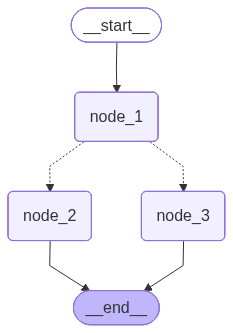

In [37]:
from langgraph.graph import StateGraph, START, END

## define the graph
builder = StateGraph(state_schema=State)    # initalize the graph state with `State`
builder.add_node('node_1', node_1)  # add nodes to graph
builder.add_node('node_2', node_2)  # add nodes to graph
builder.add_node('node_3', node_3)  # add nodes to graph

builder.add_edge(START, 'node_1')   # START is a special node that indicates where to start the graph
builder.add_conditional_edges('node_1', decide_mood)    
builder.add_edge('node_2', END)     # END is special node that indicates where to end the graph execution
builder.add_edge('node_3', END)
graph = builder.compile()   # compile the graph to perform a few basic checks on the graph
graph

In [42]:
graph.invoke(input={'graph_state' : 'Hi,'})

----node1----
----node3----


{'graph_state': 'Hi,I am Sad'}

2. Define nodes — plain Python functions that take State and return a State update:

In [ ]:
import os
from dotenv import load_dotenv
from langchain.tools import tool
from langchain_core.messages import HumanMessage
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import MessagesState
from langgraph.prebuilt import ToolNode
from langchain_community.tools import DuckDuckGoSearchResults

# 1. Load Environment Variables
load_dotenv()

# 2. Define Sample Tools
@tool
def search_web(query: str) -> str:
    """Search the web for real-time information."""
    # 1. Initialize the tool instance
    search_tool = DuckDuckGoSearchResults()
    
    # 2. Execute the search using the .invoke() method
    results = search_tool.invoke(query)
    
    return results

tools_list = [search_web]

# 3. Instantiate ToolNode (Handles all tool executions autonomously)
tool_node = ToolNode(tools_list)

# 4. Initialize LLM and Bind Tools
llm = ChatOpenAI(
    model="gpt-5-mini",  
    api_key=os.getenv("API_KEY"),
    base_url=os.getenv("BASE_URL")
).bind_tools(tools_list)

# 5. Define Graph State
class AgentState(MessagesState):
    pass

# 6. Define Agent Node Function
def agent(state: AgentState):
    response = llm.invoke(state["messages"])
    return {"messages": [response]}

# 7. Route Logic (Decides to loop to tools or finish)
def should_continue(state: AgentState):
    last_message = state["messages"][-1]
    if last_message.tool_calls:
        return "tools"
    return END

# 8. Build and Compile the Graph
workflow = StateGraph(AgentState)

workflow.add_node("agent", agent)

workflow.add_node("tools", tool_node)

workflow.add_edge(START, "agent")
workflow.add_conditional_edges("agent", should_continue)
workflow.add_edge("tools", "agent")

app = workflow.compile()

# 9. Test the Agent
if __name__ == "__main__":
    inputs = {"messages": [HumanMessage(content="What is the weather like in Ahmedabad today? Give me an answer ")]}
    for output in app.stream(inputs):
        print(output)


{'agent': {'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 64, 'prompt_tokens': 140, 'total_tokens': 204, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini', 'system_fingerprint': None, 'id': 'chatcmpl-DjKhD7McpItfRViNHoOKMHVdIjqzH', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e5e30-5589-7371-9887-05bc61310585-0', tool_calls=[{'name': 'search_web', 'args': {'query': 'Ahmedabad weather today'}, 'id': 'call_xJsp5zPuKRRZh7gGMK32hIL0', 'type': 'tool_call'}, {'name': 'search_web', 'args': {'query': 'Ahmedabad current temperature weather forecast now'}, 'id': 'call_fvDrQtltyYHfNClMZqcLMhhi', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'

In [31]:
from langgraph.prebuilt import tools_condition
import os
from dotenv import load_dotenv
from langchain.tools import tool
from langchain_core.messages import HumanMessage
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import MessagesState
from langgraph.prebuilt import ToolNode
from langchain_community.tools import DuckDuckGoSearchResults

# 1. Load Environment Variables
load_dotenv()

# 2. Define Sample Tools
@tool
def search_web(query: str) -> str:
    """Search the web for real-time information."""
    # 1. Initialize the tool instance
    search_tool = DuckDuckGoSearchResults()
    
    # 2. Execute the search using the .invoke() method
    results = search_tool.invoke(query)
    
    return results

tools_list = [search_web]

# 3. Instantiate ToolNode (Handles all tool executions autonomously)
tool_node = ToolNode(tools_list)

# 4. Initialize LLM and Bind Tools
llm = ChatOpenAI(
    model="gpt-5-mini",  
    api_key=os.getenv("API_KEY"),
    base_url=os.getenv("BASE_URL")
).bind_tools(tools_list)

# 5. Define Graph State
class AgentState(MessagesState):
    pass

# 6. Define Agent Node Function
def agent(state: AgentState):
    response = llm.invoke(state["messages"])
    return {"messages": [response]}

# 7. Route Logic (Decides to loop to tools or finish)
def should_continue(state: AgentState):
    last_message = state["messages"][-1]
    if last_message.tool_calls:
        return "tools"
    return END

# 8. Build and Compile the Graph
graph = StateGraph(AgentState)
graph.add_node("agent", agent)
graph.add_node("tools", tool_node)

graph.set_entry_point("agent")
graph.add_conditional_edges("agent", tools_condition)  # → tools OR __end__
graph.add_edge("tools", "agent")                       # always loop back

app = graph.compile()
result = app.invoke({"messages": [("user", "What's 15% of current Apple's market cap?")]})
for msg in result["messages"]:
    msg.pretty_print()

================================ Human Message =================================

What's 15% of current Apple's market cap?
================================== Ai Message ==================================
Tool Calls:
  search_web (call_ElF90tEdd8L7R5by9vR2JSod)
 Call ID: call_ElF90tEdd8L7R5by9vR2JSod
  Args:
    query: Apple market capitalization current market cap AAPL market cap today
================================= Tool Message =================================
Name: search_web

snippet: April 23, 2026 - Current and historical market capitalization for Apple Inc. (AAPL) stock, including annual, quarterly and daily history with a chart and statistics., title: Apple (AAPL) Market Cap & Net Worth, link: https://stockanalysis.com/stocks/aapl/market-cap/, snippet: 3 weeks ago - Track Apple Inc stock price on the chart and check out the list of the most volatile stocks — is Apple Inc there? ... Today Apple Inc has the market capitalization of 4.54 T, it has increased by 2.58% over the l

### LangGraph: A Tool-Calling Agent Loop

In [32]:
from langchain_openai import ChatOpenAI
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage
from langgraph.graph import StateGraph, MessagesState, START
from langgraph.prebuilt import ToolNode, tools_condition

# ── Tools ────────────────────────────────────────────────
@tool
def get_weather(city: str) -> str:
    """Get the current weather for a city."""
    return f"It's 44°C and sunny in {city}."

@tool
def calculator(expression: str) -> str:
    """Evaluate a math expression. Example: '2 + 2 * 10'"""
    try:
        return str(eval(expression))
    except Exception as e:
        return f"Error: {e}"

tools = [get_weather, calculator]

# ── Model ────────────────────────────────────────────────
llm = ChatOpenAI(
    model="gpt-5-mini",  
    api_key=os.getenv("API_KEY"),
    base_url=os.getenv("BASE_URL")
)
llm_with_tools = llm.bind_tools(tools)

# ── Agent node ───────────────────────────────────────────
def agent_node(state: MessagesState):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

# ── Graph ────────────────────────────────────────────────
graph = StateGraph(MessagesState)
graph.add_node("agent", agent_node)
graph.add_node("tools", ToolNode(tools))
graph.add_edge(START, "agent")
graph.add_conditional_edges("agent", tools_condition)
graph.add_edge("tools", "agent")
app = graph.compile()

# ── Run ──────────────────────────────────────────────────
result = app.invoke({
    "messages": [HumanMessage(content="Weather in Ahmedabad and what is 256 * 13?")]
})
print(result["messages"][-1].content)

It's 44°C and sunny in Ahmedabad.
256 × 13 = 3,328.


## Workflow and agents

Workflows have predetermined code paths and are designed to operate in a certain order.
Agents are dynamic and define their own processes and tool usage.

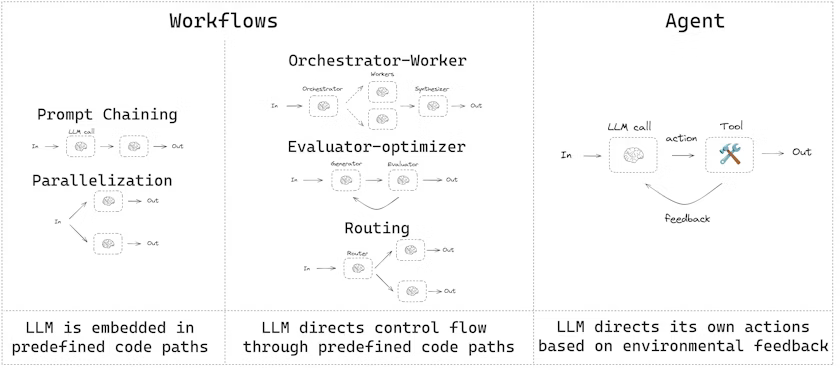

In [43]:
llm = ChatOpenAI(
    model="gpt-5-mini",  
    api_key=os.getenv("API_KEY"),
    base_url=os.getenv("BASE_URL")
)

### LLMs and augmentations

In [47]:
# Schema for structured output
from pydantic import BaseModel, Field


class SearchQuery(BaseModel):
    search_query: str = Field(None, description="Query that is optimized web search.")
    justification: str = Field(
        None, description="Why this query is relevant to the user's request."
    )


# Augment the LLM with schema for structured output
structured_llm = llm.with_structured_output(SearchQuery)

# Invoke the augmented LLM
output = structured_llm.invoke("How does Calcium CT score relate to high cholesterol?")

print(output)

# Define a tool
def multiply(a: int, b: int) -> int:
    return a * b

# Augment the LLM with tools
llm_with_tools = llm.bind_tools([multiply])

# Invoke the LLM with input that triggers the tool call
msg = llm_with_tools.invoke("What is 2 times 3?")

# Get the tool call
print(msg.tool_calls)

print(msg)

search_query='relationship between coronary artery calcium score and high cholesterol hyperlipidemia studies LDL HDL CAC score association risk prediction' justification='To find evidence-based information on how coronary artery calcium (Calcium CT / CAC) scores relate to high cholesterol (LDL, HDL, hyperlipidemia), including studies on association, predictive value, and guideline recommendations for risk assessment and management.'
[{'name': 'multiply', 'args': {'a': 2, 'b': 3}, 'id': 'call_BxyAJRNrqQGssCisn7cIRvZy', 'type': 'tool_call'}]
content='' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 128, 'total_tokens': 155, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini', 'system_fingerprint': None, 'id': 'c

### Prompt chaining

Prompt chaining is when each LLM call processes the output of the previous call. It’s often used for performing well-defined tasks that can be broken down into smaller, verifiable steps. Some examples include:

Translating documents into different languages
Verifying generated content for consistency

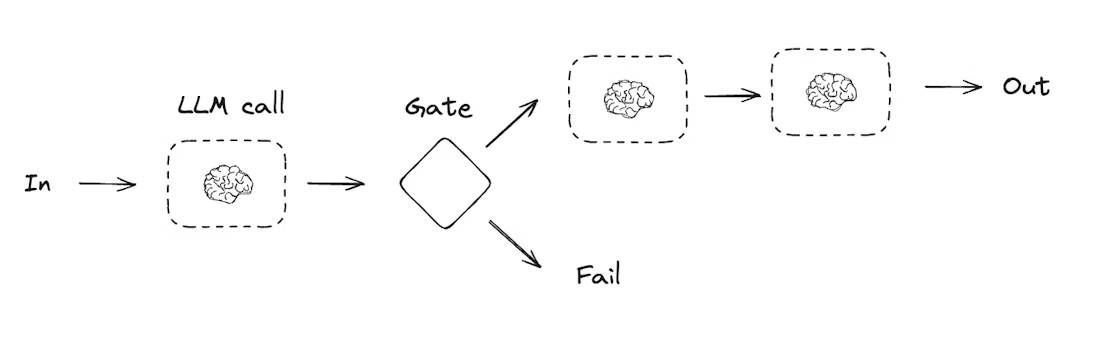

#### Graph API

In [48]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

#Graph state
class State(TypedDict):
    topic: str
    joke: str
    improved_joke: str
    final_joke: str
    
# Nodes
def generate_joke(state: State):
    """ First LLM Call to generate initial joke"""
    
    msg = llm.invoke(f"Write a short joke about {state['topic']}")
    return {"joke": msg.content}

def check_punchline(state: State):
    """ Gate function to check if the joke has a punchline"""
    
    # Simple check -  does the joke contain "?" pr "!"
    if "?" in state["joke"] or "!" in state["joke"]:
        return "Pass"
    return "Fail"

def improve_joke(state: State):
    """Second LLM call to improve the joke"""

    msg = llm.invoke(f"Make this joke funnier by adding wordplay: {state['joke']}")
    return {"improved_joke": msg.content}


def polish_joke(state: State):
    """Third LLM call for final polish"""
    msg = llm.invoke(f"Add a surprising twist to this joke: {state['improved_joke']}")
    return {"final_joke": msg.content}  

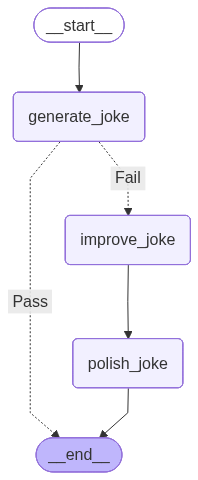

In [49]:
# Build workflow
workflow = StateGraph(State)

# Add nodes
workflow.add_node("generate_joke", generate_joke)
workflow.add_node("improve_joke", improve_joke)
workflow.add_node("polish_joke", polish_joke)

# Add edges to connect nodes
workflow.add_edge(START, "generate_joke")
workflow.add_conditional_edges(
    "generate_joke", check_punchline, {"Fail": "improve_joke", "Pass": END}
)
workflow.add_edge("improve_joke", "polish_joke")
workflow.add_edge("polish_joke", END)

# Compile
chain = workflow.compile()

# Show workflow
display(Image(chain.get_graph().draw_mermaid_png()))


In [57]:
# Invoke
state = chain.invoke({"topic": "One Punch Man"})
print("Initial joke:")
print(state["joke"])
print("\n--- --- ---\n")
if "improved_joke" in state:
    print("Improved joke:")
    print(state["improved_joke"])
    print("\n--- --- ---\n")

    print("Final joke:")
    print(state["final_joke"])
else:
    print("Final joke:")
    print(state["joke"])

Initial joke:
Why did Saitama go to the job interview?

Because he heard they were looking for someone with "killer" skills — and he takes that literally.

--- --- ---

Final joke:
Why did Saitama go to the job interview?

Because he heard they were looking for someone with "killer" skills — and he takes that literally.


#### Functional API

In [58]:
from langgraph.func import entrypoint, task


# Tasks
@task
def generate_joke(topic: str):
    """First LLM call to generate initial joke"""
    msg = llm.invoke(f"Write a short joke about {topic}")
    return msg.content


def check_punchline(joke: str):
    """Gate function to check if the joke has a punchline"""
    # Simple check - does the joke contain "?" or "!"
    if "?" in joke or "!" in joke:
        return "Fail"

    return "Pass"


@task
def improve_joke(joke: str):
    """Second LLM call to improve the joke"""
    msg = llm.invoke(f"Make this joke funnier by adding wordplay: {joke}")
    return msg.content


@task
def polish_joke(joke: str):
    """Third LLM call for final polish"""
    msg = llm.invoke(f"Add a surprising twist to this joke: {joke}")
    return msg.content


In [62]:
@entrypoint()
def prompt_chaining_workflow(topic: str):
    original_joke = generate_joke(topic).result()
    if check_punchline(original_joke) == "Pass":
        return original_joke

    improved_joke = improve_joke(original_joke).result()
    return polish_joke(improved_joke).result()

# Invoke
for step in prompt_chaining_workflow.stream("Garou", stream_mode="updates"):
    print(step)
    print("\n")

{'generate_joke': 'Why did Garou stop training with monsters?\n\nHe realized the only thing he couldn’t beat was his morning alarm!'}


{'improve_joke': 'Why did Garou stop training with monsters?\n\nHe realized the only thing he couldn’t beat was his morning alarm — turns out you can KO beasts, but you can’t punch the snooze button into submission.'}


{'polish_joke': 'Why did Garou stop training with monsters?\n\nHe realized the only thing he couldn’t beat was his morning alarm — turns out you can KO beasts, but you can’t punch the snooze button into submission. Then one morning the alarm answered back: it had been training too, and it was the one thing that could always hit him until he learned to hit bedtime instead.'}


{'prompt_chaining_workflow': 'Why did Garou stop training with monsters?\n\nHe realized the only thing he couldn’t beat was his morning alarm — turns out you can KO beasts, but you can’t punch the snooze button into submission. Then one morning the alarm answered b

### Parallelization

With parallelization, LLMs work simultaneously on a task. This is either done by running multiple independent subtasks at the same time, or running the same task multiple times to check for different outputs. Parallelization is commonly used to:

    Split up subtasks and run them in parallel, which increases speed
    Run tasks multiple times to check for different outputs, which increases confidence


Some examples include:

    Running one subtask that processes a document for keywords, and a second subtask to check for formatting errors
    
    Running a task multiple times that scores a document for accuracy based on different criteria, like the number of citations, the number of sources used, and the quality of the sources


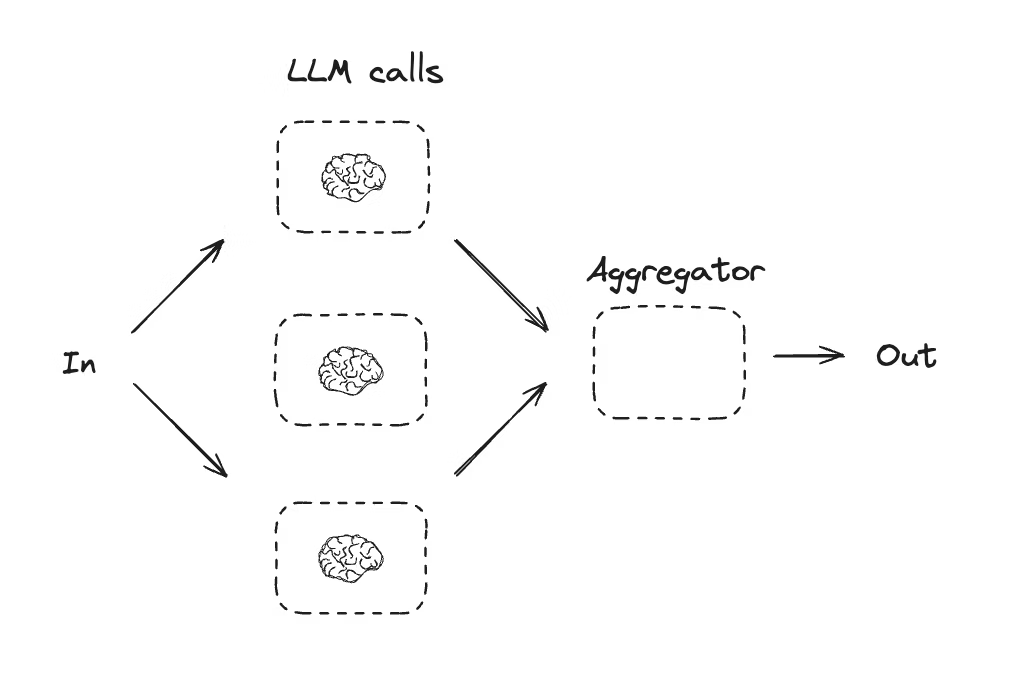

#### Graph API

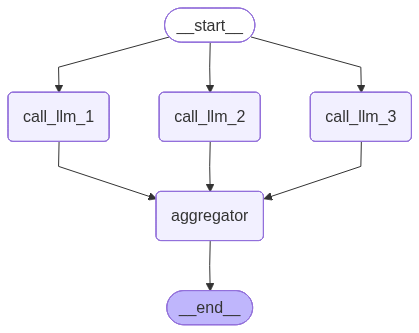

Here's a story, joke, and poem about one punch man!

STORY:
Saitama spat a stray hair from his face and watched, with mild curiosity, as morning commuters squeezed past a low-hanging banner advertising a sale on prosthetic arms. The city smelled faintly of ozone and burnt coffee; somewhere down an alley a monster-smasher did his stretching routine with the intensity of a man who believed in his muscles as moral philosophy. Saitama yawned. It was Tuesday, which meant at least one villain would rampage somewhere, and that would be that.

He had not always been exactly bored. Once, the rush had been real: the thrumming fear in his bones, the jagged adrenaline that turned time into a slow, treacherous thing. But for years now, threats came and went like morning fog. He still trained every day because the habit mattered, because an ordinary face preferred ordinary discipline. He still clipped his fingernails with the kind of mechanical efficiency that made housewives envious. A hero was a h

In [64]:
# Graph state
class State(TypedDict):
    topic: str
    joke: str
    story: str
    poem: str
    combined_output: str


# Nodes
def call_llm_1(state: State):
    """First LLM call to generate initial joke"""

    msg = llm.invoke(f"Write a joke about {state['topic']}")
    return {"joke": msg.content}


def call_llm_2(state: State):
    """Second LLM call to generate story"""

    msg = llm.invoke(f"Write a story about {state['topic']}")
    return {"story": msg.content}


def call_llm_3(state: State):
    """Third LLM call to generate poem"""

    msg = llm.invoke(f"Write a poem about {state['topic']}")
    return {"poem": msg.content}


def aggregator(state: State):
    """Combine the joke, story and poem into a single output"""

    combined = f"Here's a story, joke, and poem about {state['topic']}!\n\n"
    combined += f"STORY:\n{state['story']}\n\n"
    combined += f"JOKE:\n{state['joke']}\n\n"
    combined += f"POEM:\n{state['poem']}"
    return {"combined_output": combined}


# Build workflow
parallel_builder = StateGraph(State)

# Add nodes
parallel_builder.add_node("call_llm_1", call_llm_1)
parallel_builder.add_node("call_llm_2", call_llm_2)
parallel_builder.add_node("call_llm_3", call_llm_3)
parallel_builder.add_node("aggregator", aggregator)

# Add edges to connect nodes
parallel_builder.add_edge(START, "call_llm_1")
parallel_builder.add_edge(START, "call_llm_2")
parallel_builder.add_edge(START, "call_llm_3")
parallel_builder.add_edge("call_llm_1", "aggregator")
parallel_builder.add_edge("call_llm_2", "aggregator")
parallel_builder.add_edge("call_llm_3", "aggregator")
parallel_builder.add_edge("aggregator", END)
parallel_workflow = parallel_builder.compile()

# Show workflow
display(Image(parallel_workflow.get_graph().draw_mermaid_png()))

# Invoke
state = parallel_workflow.invoke({"topic": "one punch man"})
print(state["combined_output"])

#### Functional API

In [67]:
@task
def call_llm_1(topic: str):
    """First LLM call to generate initial joke"""
    msg = llm.invoke(f"Write a joke about {topic}")
    return msg.content


@task
def call_llm_2(topic: str):
    """Second LLM call to generate story"""
    msg = llm.invoke(f"Write a story about {topic}")
    return msg.content


@task
def call_llm_3(topic):
    """Third LLM call to generate poem"""
    msg = llm.invoke(f"Write a poem about {topic}")
    return msg.content


@task
def aggregator(topic, joke, story, poem):
    """Combine the joke and story into a single output"""

    combined = f"Here's a story, joke, and poem about {topic}!\n\n"
    combined += f"STORY:\n{story}\n\n"
    combined += f"JOKE:\n{joke}\n\n"
    combined += f"POEM:\n{poem}"
    return combined


# Build workflow
@entrypoint()
def parallel_workflow(topic: str):
    joke_fut = call_llm_1(topic)
    story_fut = call_llm_2(topic)
    poem_fut = call_llm_3(topic)
    return aggregator(
        topic, joke_fut.result(), story_fut.result(), poem_fut.result()
    ).result()

# Invoke
for step in parallel_workflow.stream("Garou", stream_mode="updates"):
    print(step)
    print("\n")

{'call_llm_1': "Sure — here's one:\n\nWhy did Garou bring a ladder to the hero convention?\n\nBecause he heard the heroes were on another level... and he wanted to beat them to the top!"}


{'call_llm_3': "Garou stalks the night between growl and grin,\nA lone wolf's shadow where the city lights thin.\nFur matted with rain, hands stained by the fight,\nHe dances on edges of wrong and of right.\n\nOld scars map his chest like a stubborn refrain,\nEach memory a thunder that runs through his veins.\nHe hunts not for hunger but for something like peace,\nA promise of stillness where his battles might cease.\n\nHe speaks to the moon as if it knows his name,\nRecalling the faces that burned in the flame.\nOnce a boy with a future, now a legend of scars,\nHe keeps walking onward beneath indifferent stars.\n\nThere’s fury in footsteps, and grace in the stride,\nA fracture of honor he carries inside.\nWhen the world turns its back and the innocents fall,\nGarou answers the silence — he rises, h

### Routing

Routing workflows process inputs and then directs them to context-specific tasks. This allows you to define specialized flows for complex tasks. For example, a workflow built to answer product related questions might process the type of question first, and then route the request to specific processes for pricing, refunds, returns, etc.

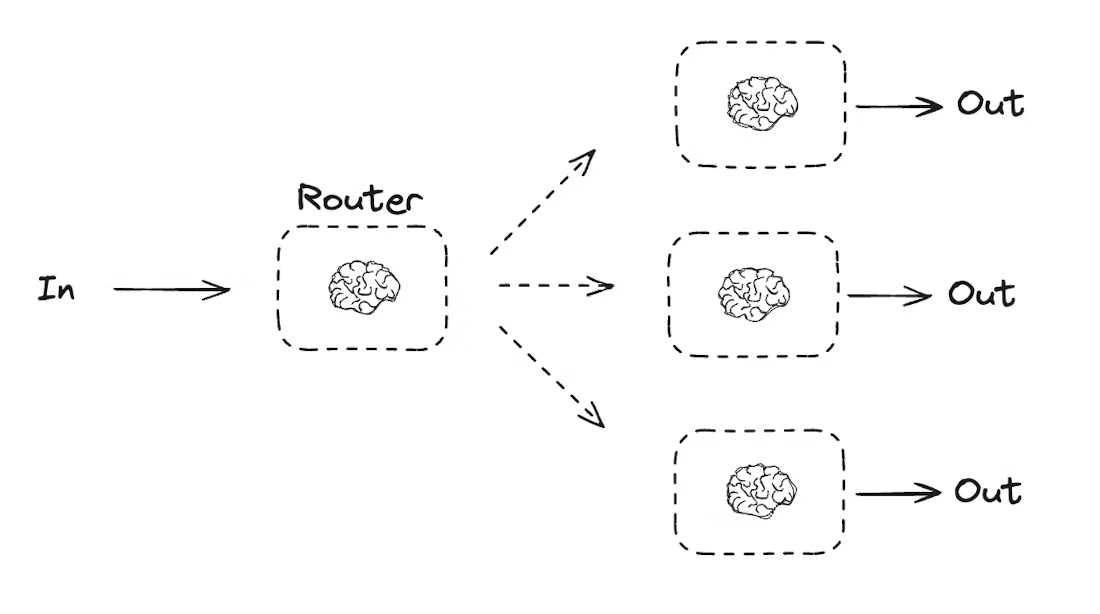

#### Graph_API

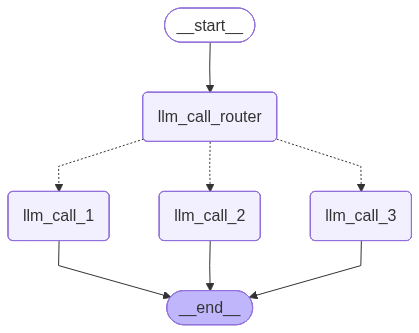

Why did the cat sit on the computer? It wanted to keep an eye on the mouse — and make sure the cursor didn't get any ideas.


In [69]:
from typing_extensions import Literal
from langchain.messages import HumanMessage, SystemMessage


# Schema for structured output to use as routing logic
class Route(BaseModel):
    step: Literal["poem", "story", "joke"] = Field(
        None, description="The next step in the routing process"
    )


# Augment the LLM with schema for structured output
router = llm.with_structured_output(Route)


# State
class State(TypedDict):
    input: str
    decision: str
    output: str


# Nodes
def llm_call_1(state: State):
    """Write a story"""

    result = llm.invoke(state["input"])
    return {"output": result.content}


def llm_call_2(state: State):
    """Write a joke"""

    result = llm.invoke(state["input"])
    return {"output": result.content}


def llm_call_3(state: State):
    """Write a poem"""

    result = llm.invoke(state["input"])
    return {"output": result.content}


def llm_call_router(state: State):
    """Route the input to the appropriate node"""

    # Run the augmented LLM with structured output to serve as routing logic
    decision = router.invoke(
        [
            SystemMessage(
                content="Route the input to story, joke, or poem based on the user's request."
            ),
            HumanMessage(content=state["input"]),
        ]
    )

    return {"decision": decision.step}


# Conditional edge function to route to the appropriate node
def route_decision(state: State):
    # Return the node name you want to visit next
    if state["decision"] == "story":
        return "llm_call_1"
    elif state["decision"] == "joke":
        return "llm_call_2"
    elif state["decision"] == "poem":
        return "llm_call_3"


# Build workflow
router_builder = StateGraph(State)

# Add nodes
router_builder.add_node("llm_call_1", llm_call_1)
router_builder.add_node("llm_call_2", llm_call_2)
router_builder.add_node("llm_call_3", llm_call_3)
router_builder.add_node("llm_call_router", llm_call_router)

# Add edges to connect nodes
router_builder.add_edge(START, "llm_call_router")
router_builder.add_conditional_edges(
    "llm_call_router",
    route_decision,
    {  # Name returned by route_decision : Name of next node to visit
        "llm_call_1": "llm_call_1",
        "llm_call_2": "llm_call_2",
        "llm_call_3": "llm_call_3",
    },
)
router_builder.add_edge("llm_call_1", END)
router_builder.add_edge("llm_call_2", END)
router_builder.add_edge("llm_call_3", END)

# Compile workflow
router_workflow = router_builder.compile()

# Show the workflow
display(Image(router_workflow.get_graph().draw_mermaid_png()))

# Invoke
state = router_workflow.invoke({"input": "Write me a joke about cats"})
print(state["output"])

#### Functional API

In [70]:
from typing_extensions import Literal
from pydantic import BaseModel
from langchain.messages import HumanMessage, SystemMessage


# Schema for structured output to use as routing logic
class Route(BaseModel):
    step: Literal["poem", "story", "joke"] = Field(
        None, description="The next step in the routing process"
    )


# Augment the LLM with schema for structured output
router = llm.with_structured_output(Route)


@task
def llm_call_1(input_: str):
    """Write a story"""
    result = llm.invoke(input_)
    return result.content


@task
def llm_call_2(input_: str):
    """Write a joke"""
    result = llm.invoke(input_)
    return result.content


@task
def llm_call_3(input_: str):
    """Write a poem"""
    result = llm.invoke(input_)
    return result.content


def llm_call_router(input_: str):
    """Route the input to the appropriate node"""
    # Run the augmented LLM with structured output to serve as routing logic
    decision = router.invoke(
        [
            SystemMessage(
                content="Route the input to story, joke, or poem based on the user's request."
            ),
            HumanMessage(content=input_),
        ]
    )
    return decision.step


# Create workflow
@entrypoint()
def router_workflow(input_: str):
    next_step = llm_call_router(input_)
    if next_step == "story":
        llm_call = llm_call_1
    elif next_step == "joke":
        llm_call = llm_call_2
    elif next_step == "poem":
        llm_call = llm_call_3

    return llm_call(input_).result()

# Invoke
for step in router_workflow.stream("Write me a joke about cats", stream_mode="updates"):
    print(step)
    print("\n")

{'llm_call_2': 'Why did the cat sit on the computer?\n\nIt wanted to keep an eye on the mouse!'}


{'router_workflow': 'Why did the cat sit on the computer?\n\nIt wanted to keep an eye on the mouse!'}


